# iSPy: Inferring Spatial Ploidy — minimal reproduction (Drosophila pylorus, uninjured)

Reproduction of the Gaussian-mixture ploidy classification from:
**Russell N.J. et al., _Spatial ploidy inference using quantitative imaging_**, bioRxiv 2025 (DOI: [10.1101/2025.03.11.642217](https://doi.org/10.1101/2025.03.11.642217)); journal version: *Cell Reports Methods* 5(12):101249 (PMC12859483).
Author code: **iSPy** by Nicholas J. Russell (MPIPZ), GitLab `devplantpatterning/Publications/ispy-inferring-spatial-ploidy`, pinned commit `8c2c51c317c4` (MIT license), also mirrored on OSF (node `tgbwk`).

**Scope (executed demonstration, one example):** iSPy 1D + 2D unsupervised Gaussian-mixture ploidy classification of one *Drosophila* pylorus sample (Uninjured, Experiment 1; 579 hand-selected nuclei) from the authors' OSF release (node `wkaf5`, "Drosophila Data"), including the paper's spermatid normalization and a colored **spatial ploidy map** comparable to Figure 3F (uninjured panel). This is a single-example demonstration — it does **not** reproduce the dataset-level comparison across injury severities, the Arabidopsis/heart analyses, or the flow-cytometry validation.

**実行内容（日本語）:** 論文の iSPy（ガウシアン混合モデルによる倍数性分類）を、著者公開コード（pinned commit）と OSF 公開データの実例 1 サンプル（未損傷 pylorus）で再現します。精子核（1C）による正規化、1D/2D GMM、空間的な倍数性マップ（Fig. 3F 相当）を含みます。単一サンプルのデモであり、損傷条件間の比較やデータセット全体の検証は含みません。

**Execution status:** this notebook is executed end-to-end on a fresh Colab **CPU** runtime (no GPU is required — the method is scikit-learn GMM on ~600 points). Results shown are from the archived validation run of this exact notebook.


## Runtime selection

**Select Runtime → Change runtime type → CPU** (the default). No GPU is needed: the whole pipeline is `scikit-learn.GaussianMixture` on 579 points plus image plotting (~17 MB of downloads). Expected wall time is dominated by the authors' thorough GMM restart settings (`n_init=20` for 1D, `n_init=500` for 2D; see the pinned `Curve_Fitting_SKLearn.py`), roughly 20–40 minutes total on a free CPU runtime.

**ランタイム（日本語）:** GPU は不要です（CPU で十分）。著者コードの `n_init` 設定が丁寧なため、全体で 20〜40 分程度かかります。

Run all cells top-to-bottom (`Runtime → Run all`). All downloads (author code files + sample data) happen inside this notebook into `/content`.


### Environment check

Verify that all packages required by the pinned iSPy code (README table: numpy, pandas, matplotlib, scikit-learn, scipy, h5py, tifffile) are importable and print their versions. Everything is preinstalled on current Colab runtimes; the cell fails loudly if something essential is missing.

**環境チェック（日本語）:** 著者コードが要求するパッケージが揃っているか確認し、バージョンを表示します。Colab にはすべてプリインストールされています。


In [ ]:
import sys, numpy, pandas, matplotlib, sklearn, scipy, h5py, tifffile
print('Python', sys.version.split()[0])
for m in (numpy, pandas, matplotlib, sklearn, scipy, h5py, tifffile):
    print(f'{m.__name__:>12} {m.__version__}')

Python 3.13.15
       numpy 2.1.3
      pandas 2.2.3
  matplotlib 3.10.0
     sklearn 1.6.1
       scipy 1.16.3
        h5py 3.16.0
    tifffile 2026.9.15


### Fetch the pinned author code (Colab-side, sha256-verified)

The iSPy tools modules are fetched **inside the notebook** from the author's GitLab at the exact pinned commit `8c2c51c317c4` via the public API v4 raw endpoint (the web UI requires sign-in, the API does not). Each file's SHA-256 is asserted against the hash recorded from the same commit, so the code executed here is bit-identical to the author's repository. Files land in `/content/ispy/` and are added to `sys.path`.

**著者コード取得（日本語）:** 著者の GitLab から pinned commit `8c2c51c317c4` のコードファイルのみをダウンロードし、SHA-256 で検証します（リポジトリの clone ではなく、必要なコードファイルのみ）。


In [ ]:
import urllib.request, urllib.parse, hashlib, os

COMMIT = '8c2c51c317c4'
BASE = ('https://gitlab.gwdg.de/api/v4/projects/'
        'devplantpatterning%2FPublications%2Fispy-inferring-spatial-ploidy'
        '/repository/files')
# relative path -> expected sha256 (recorded from commit 8c2c51c317c4)
CODE_FILES = {
    'tools/basics/Character_Class.py':
        'b2a6da97e9d38192ea074cc349eaf578e069aee115a84b718f143ef88787c478',
    'tools/basics/Plotting_Definitions_Class.py':
        'b77f329b55729c4b00c72ff0d8cd6baf7135000bec07ded78b8c9d3281400534',
    'tools/curve_fitting/Curve_Fitting_SKLearn.py':
        '853d5466651cc50dbffb9032641eac9bb63e81447e4cd990c4ee1dd0b8aace18',
    'tools/curve_fitting/Curve_Fitting_Plotting.py':
        '2849b9046c9ebabeda757c49ebd59baab50516331b6db5af0b26f50ae4eab23a',
    'tools/image_output/Image_Output.py':
        'f8bb0dceb6caa9f028e786fe6c29ff00f4683c4eb4c5b8f7af1204d23d39ba5a',
}
for rel, sha in CODE_FILES.items():
    dst = os.path.join('/content/ispy', rel)
    os.makedirs(os.path.dirname(dst), exist_ok=True)
    urllib.request.urlretrieve(f'{BASE}/{urllib.parse.quote(rel, safe="")}/raw?ref={COMMIT}', dst)
    h = hashlib.sha256(open(dst, 'rb').read()).hexdigest()
    assert h == sha, f'{rel}: sha256 mismatch ({h})'
    print('verified', rel, h[:12])

verified tools/basics/Character_Class.py b2a6da97e9d3


verified tools/basics/Plotting_Definitions_Class.py b77f329b5572


verified tools/curve_fitting/Curve_Fitting_SKLearn.py 853d5466651c


verified tools/curve_fitting/Curve_Fitting_Plotting.py 2849b9046c9e


verified tools/image_output/Image_Output.py f8bb0dceb6ca


### Import the author's iSPy modules

With the verified files in place we import the author's own classes and functions — `Characteristic`/`Plotting` (feature handling), `Plot` (scatter + histograms), `Full_CurveFits` (1D/2D Gaussian-mixture search), and `PredictionImage` (colored spatial map). The notebook drives the author's code rather than re-implementing it.

**インポート（日本語）:** 検証済みの著者モジュールをそのまま利用します（再実装ではありません）。


In [ ]:
import sys
sys.path.insert(0, '/content/ispy')

import tools.basics.Character_Class as Class
from tools.basics.Plotting_Definitions_Class import Plot
from tools.curve_fitting.Curve_Fitting_SKLearn import Full_CurveFits
from tools.image_output.Image_Output import PredictionImage
print('iSPy modules imported from pinned commit', '8c2c51c317c4')

iSPy modules imported from pinned commit 8c2c51c317c4


### Download the minimal sample from the authors' OSF release (sha256-verified)

From OSF node `wkaf5` (*Drosophila Data*), we fetch only the files needed for one sample — **Uninjured / Experiment 1 / Pylorus**:
`Images/SUM_Projection_1.tif` (sum projection), `ilastik/Data_Table_1.csv` (per-nucleus features), `ilastik/Object_Identities_1.h5` (segmentation labels), plus **Sperm / ilastik/Data_Table_1.csv and Data_Table_2.csv** (haploid 1C spermatids from the two testes on the same slide, used for the paper's normalization). Downloads go through the public `osf.io/download/<guid>` route with bounded retries (the endpoint rate-limits briefly) and every file is checked against its recorded size and SHA-256.

**サンプルデータ取得（日本語）:** 未損傷 pylorus 1 サンプルに必要な 4 ファイルのみを OSF から取得し、サイズと SHA-256 を検証します（429 対応のリトライ付き）。


In [ ]:
import time

SAMPLE = {
    'SUM_Projection_1.tif':   ('67bcb97d1816c0d9fb6cc7d0', 2344091,
                               'abe0ac5b3d0e0ac71061861d19fded679a82ae6c986c6cd549f5a312e0e5514d'),
    'Data_Table_1.csv':       ('67bcb988f4a019f51ed4cce9', 488131,
                               '83e0f504788790a7ed23c53517dd7ad2c9897b476de14d0968339b81e655fc70'),
    'Object_Identities_1.h5': ('67bcb9870ec1e3dcc02debaa', 4610296,
                               'a948d33e5cf3b545e5e58d323dcbdc9ba6c40578c5286e97153b7e0fb5ca2085'),
    'Sperm_Data_Table_1.csv': ('67bcb9a11816c0d9fb6cc7db', 36836,
                               'eb4404401c30d0cd22d9e67e0456170fe6d586a71cb94dde64d5379dadb21036'),
    'Sperm_Data_Table_2.csv': ('67bcb9a21b12ca2444d4c2fa', 30615,
                               'b02b8d089e3dbc6b157c9aa50b252a294d2d5f2468244d7ec4a54412e2ded0a0'),
}
os.makedirs('/content/data', exist_ok=True)

def osf_download(name, guid, size, sha, attempts=6):
    dst = '/content/data/' + name
    for i in range(attempts):
        try:
            with urllib.request.urlopen(f'https://osf.io/download/{guid}/', timeout=120) as r:
                blob = r.read()
            assert len(blob) == size, (name, len(blob), size)
            assert hashlib.sha256(blob).hexdigest() == sha, name
            open(dst, 'wb').write(blob)
            print('verified', name, len(blob), 'bytes')
            return
        except Exception as e:
            print(f'{name}: attempt {i} failed ({e}); retrying')
            time.sleep(20 * (i + 1))
    raise RuntimeError('download failed: ' + name)

for name, (guid, size, sha) in SAMPLE.items():
    osf_download(name, guid, size, sha)

verified SUM_Projection_1.tif 2344091 bytes


verified Data_Table_1.csv 488131 bytes


verified Object_Identities_1.h5 4610296 bytes


verified Sperm_Data_Table_1.csv 36836 bytes


verified Sperm_Data_Table_2.csv 30615 bytes


## Input preview: sum projection and ilastik segmentation

The sample is an 897x871 sum projection of a squashed *Drosophila* pylorus stained with Hoechst. The ilastik Object Identities file (`exported_data`, uint32) stores one label per segmented nucleus; the feature CSV has 770 rows. In the CSV, the authors hand-labeled 191 objects as **'Bad Nuclei'** (incomplete/badly segmented nuclei — per the paper's Methods, incomplete nuclei were hand-selected and removed); the remaining 579 are the analyzed pyloric nuclei. We display (left) the Hoechst sum projection and (right) the segmentation with the excluded 'Bad Nuclei' marked in red, so the annotation that the paper's manual step produced is visible.

**入力プレビュー（日本語）:** 左が Hoechst 和投影画像、右が ilastik セグメンテーション。赤で示した 191 個は著者が手作業で 'Bad Nuclei'（不完全核）と印を付けたもので、解析から除外されます（残り 579 核）。


sum projection: (897, 871, 3) uint8
object identities: (897, 871) uint32 max label 770
CSV rows: 770 | columns: 77
User Label
0             579
Bad Nuclei    191


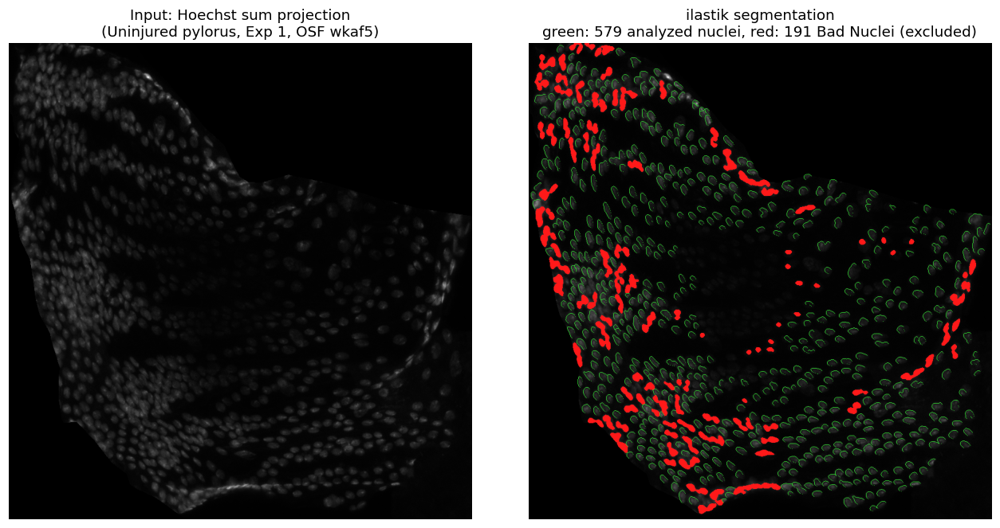

In [ ]:
import numpy as np, pandas as pd, h5py, tifffile
import matplotlib.pyplot as plt

proj = tifffile.imread('/content/data/SUM_Projection_1.tif')          # (H, W, 3) uint8
print('sum projection:', proj.shape, proj.dtype)
with h5py.File('/content/data/Object_Identities_1.h5', 'r') as f:
    labels = np.array(f['exported_data'][:, :, 0])                    # (H, W) uint32
print('object identities:', labels.shape, labels.dtype, 'max label', labels.max())

df_all = pd.read_csv('/content/data/Data_Table_1.csv')
print('CSV rows:', len(df_all), '| columns:', len(df_all.columns))
print(df_all['User Label'].value_counts().to_string())

bad = (df_all['User Label'] == 'Bad Nuclei').to_numpy()
oid = df_all['labelimage_oid'].to_numpy(dtype=int)
overlay = (proj.astype(float) / 255.0)
red = np.isin(labels, oid[bad])
edge = np.isin(labels, oid[~bad]) & (labels != np.roll(labels, 1, 0)) |        (np.isin(labels, oid[~bad]) & (labels != np.roll(labels, 1, 1)))
overlay[edge] = [0.2, 0.9, 0.2]        # green outlines: analyzed nuclei
overlay[red] = [1.0, 0.1, 0.1]         # red: 'Bad Nuclei' (excluded)

fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=110)
axes[0].imshow(proj); axes[0].set_title('Input: Hoechst sum projection\n(Uninjured pylorus, Exp 1, OSF wkaf5)')
axes[1].imshow(overlay); axes[1].set_title('ilastik segmentation\ngreen: 579 analyzed nuclei, red: 191 Bad Nuclei (excluded)')
for ax in axes: ax.set_axis_off()
plt.tight_layout(); plt.show()

### Feature columns used by iSPy

The ilastik CSV stores channel-suffixed columns; the Hoechst signal is channel 0 (`Total Intensity_0`) and the projected nuclear area is `Size in pixels`. The three ilastik channel slots carry identical values here (single-stain export), so channel 0 is unambiguous. We print summary statistics of both features for the 579 analyzed nuclei — these are the raw values that the next cell normalizes.

**特徴量（日本語）:** Hoechst 全強度は `Total Intensity_0`、投影核面積は `Size in pixels`（単一染色のためチャネル 0 で確定）。次のセルで精子核 median により正規化します。


In [ ]:
kept = df_all[df_all['User Label'] != 'Bad Nuclei']
cols = ['Total Intensity_0', 'Size in pixels']
print(kept[cols].describe().loc[['count', 'min', '25%', '50%', '75%', 'max']].to_string())
sp = pd.read_csv('/content/data/Sperm_Data_Table_1.csv')
print('\nspermatids (1C):', len(sp), 'nuclei; Total Intensity_0 median =', sp['Total Intensity_0'].median())

       Total Intensity_0  Size in pixels
count              579.0           579.0
min                872.0            53.0
25%               3552.0           126.0
50%               4722.0           156.0
75%               5595.0           185.0
max              16848.0           391.0

spermatids (1C): 54 nuclei; Total Intensity_0 median = 5909.5


## Paper step: normalize Hoechst intensity to haploid spermatids

The paper's Methods: *"we normalized the total Hoechst intensity of the pyloric nuclei to the median intensity of the haploid spermatids from the same experiment"*. We therefore divide `Total Intensity_0` of every pyloric nucleus by the median `Total Intensity_0` of the hand-selected complete spermatids ('Best Sperm Nuclei') from the two sperm tables of the same experiment (slide), drop the 191 'Bad Nuclei' rows (paper's hand-selection of complete nuclei), and write the processed CSV that is fed to the author's pipeline. After normalization, 1C (haploid genome content) ≈ 1, so a nucleus at ~2 is 2C, ~4 is 4C, etc.

**正規化（日本語）:** 論文の Methods に従い、同一実験の two sperm テーブルから手選択された完全な精子核（'Best Sperm Nuclei'）の Total Intensity の median で正規化し、'Bad Nuclei' を除いた 579 核の CSV を作成します。正規化後は 1C≈1 となります。


In [ ]:
sp2 = pd.read_csv('/content/data/Sperm_Data_Table_2.csv')
# hand-selected complete spermatids ('Best Sperm Nuclei') from both testes of Experiment 1
best1 = sp[sp['User Label'] == 'Best Sperm Nuclei']['Total Intensity_0']
best2 = sp2[sp2['User Label'] == 'Best Sperm Nuclei']['Total Intensity_0']
med_sperm = pd.concat([best1, best2]).median()
proc = df_all[df_all['User Label'] != 'Bad Nuclei'].copy()
proc['Total Intensity_0'] = proc['Total Intensity_0'] / med_sperm
os.makedirs('/content/proc', exist_ok=True)
PROC_CSV = '/content/proc/pylorus_uninjured_exp1_norm.csv'
proc.to_csv(PROC_CSV, index=False)
print('spermatids used: %d (Best Sperm Nuclei from both sperm tables); median (1C) = %.1f' % (len(best1) + len(best2), med_sperm))
print('normalized intensity: min %.3f  median %.3f  max %.3f' %
      (proc['Total Intensity_0'].min(), proc['Total Intensity_0'].median(), proc['Total Intensity_0'].max()))
print('nuclei kept:', len(proc))

spermatids used: 47 (Best Sperm Nuclei from both sperm tables); median (1C) = 3004.0
normalized intensity: min 0.290  median 1.572  max 5.609
nuclei kept: 579


### Configure iSPy characteristics (author parameter style)

We instantiate the author's `Characteristic` objects exactly as in the authors' `Two_Characteristics.ipynb` template, with two paper-driven changes: the feature columns are the ilastik channel-suffixed names (`Total Intensity_0` for normalized Hoechst intensity, `Size in pixels` for projected nuclear area), and 60 histogram bins on log2-scaled axes (paper Fig. 3B uses log-scaled axes; the author template default is 60 bins). Log base 2 is the iSPy default so successive ploidy peaks are evenly spaced. The pinned commit's `Characteristic` constructor takes one extra argument (`Column_ID_Label='labelimage_oid'`) compared to the older template shipped in the repository — we pass it per the current code signature.

**設定（日本語）:** 著者のテンプレートに従い log2 スケール・60 bin で 2 特徴量を設定します。pinned commit ではコンストラクタ引数が 1 つ増えているため、現在のシグネチャに合わせています。


In [ ]:
Char1 = Class.Characteristic('Total Intensity_0', 'None', 5, 'Log', 2,
                             'Number', 60, 'Normalized Hoechst intensity (1C = sperm median)',
                             False, 1, 0, 0, 0, 0, [], 'labelimage_oid')
Char2 = Class.Characteristic('Size in pixels', 'None', 5, 'Log', 2,
                             'Number', 60, 'Projected nuclear area (pixels)',
                             False, 2, 0, 0, 0, 0, [], 'labelimage_oid')
Files = [PROC_CSV]
Legends = ['Uninjured pylorus (Exp 1)']
PlotScheme = Class.Plotting(
    ['#882255', '#AA4499', '#CC6677', '#DDCC77', '#88CCEE', '#44AA99', '#117733', '#332288'],
    0, 'Set3', ['o', 'd', '^', 's', 'P', 'x'], 10,
    indvplot=1, AIC=1, BIC=1, save_data=1, readme=1,
    pngs=1, pdfs=0, svgs=0, dark=0, exp_str='ispy_colab', object=0, object_name=0)
print('Characteristics and PlotScheme configured')

Characteristics and PlotScheme configured


### Author pipeline: scatter plot with marginal histograms

This calls the author's `Plot` on the normalized CSV — the same figure type as paper Fig. 3B (scatter of projected nuclear area vs normalized Hoechst intensity with marginal histograms on log2 axes), here for the single uninjured sample. Note the projected area is in pixels because ilastik does not store voxel size; this does not affect the GMM classification (a constant scale factor only shifts the log2 axis).

**散布図（日本語）:** 著者コードの `Plot` で Fig. 3B 型の散布図＋周辺ヒストグラム（log2 軸）を描きます。面積はピクセル単位ですが、定数倍は log2 軸の平行移動に過ぎず分類に影響しません。


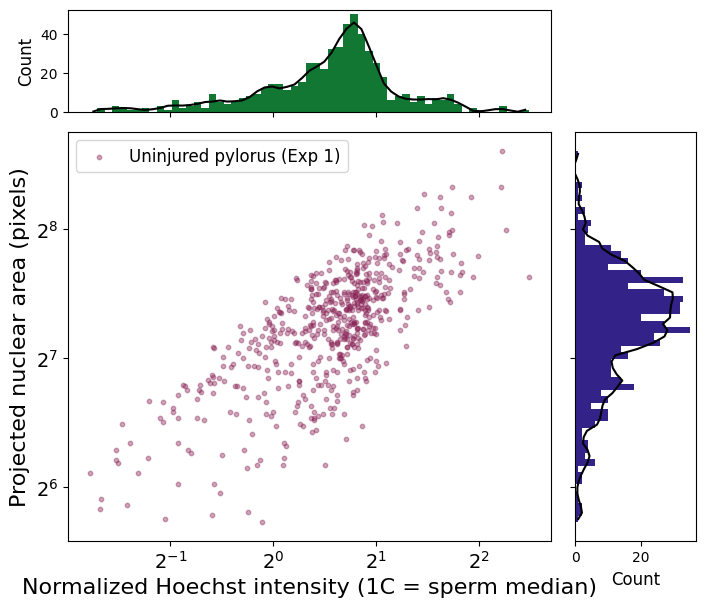

basic plots done


<Figure size 640x480 with 0 Axes>

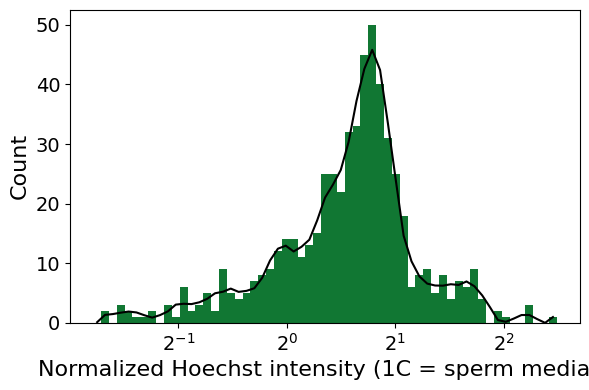

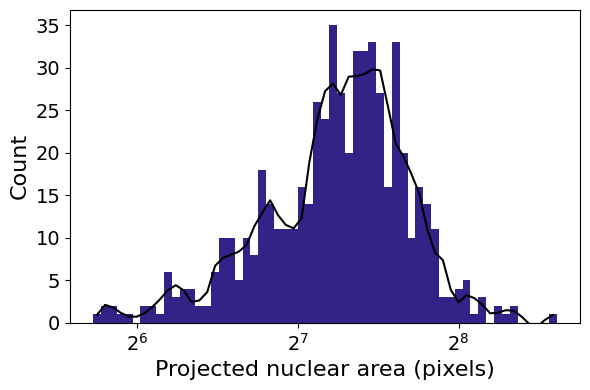

In [ ]:
Plot(Files, Legends, Char1, Char2, 2, [1, 1, 1], PlotScheme)
print('basic plots done')

### 1D Gaussian mixtures on each characteristic (author code, AIC/BIC search 1–6)

`Full_CurveFits` with `curvefit_1d=1` runs the author's 1D GMM search for **both** characteristics: number of components 1–6, and AIC + BIC model selection, with the author's exact optimizer settings (`n_init=20`, `tol=1e-5`, `max_iter=10000`; covariance types per the pinned code). This is the paper's 1D analysis (Fig. S5 A, F): for the uninjured data the paper reports six components optimal by AIC and two by BIC for intensity, five/four for area. This cell takes several minutes.

**1D GMM（日本語）:** 著者コードの設定（n_init=20 など）のまま、成分数 1〜6・AIC/BIC で各特徴量の 1D 混合モデルを探索します（数分かかります）。


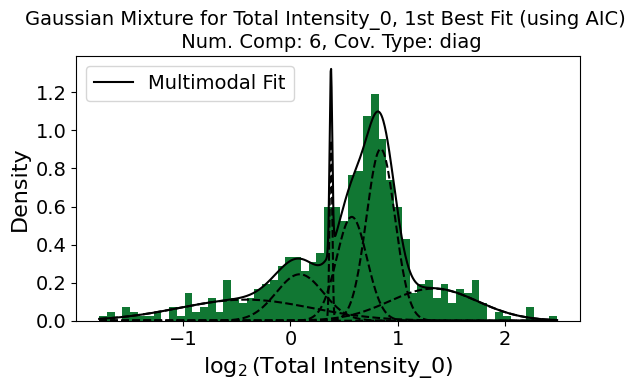

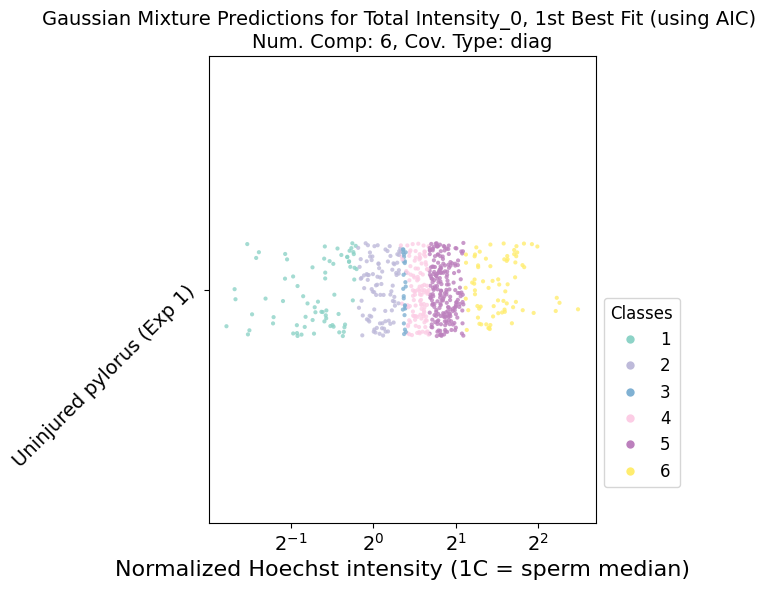

<Figure size 640x480 with 0 Axes>

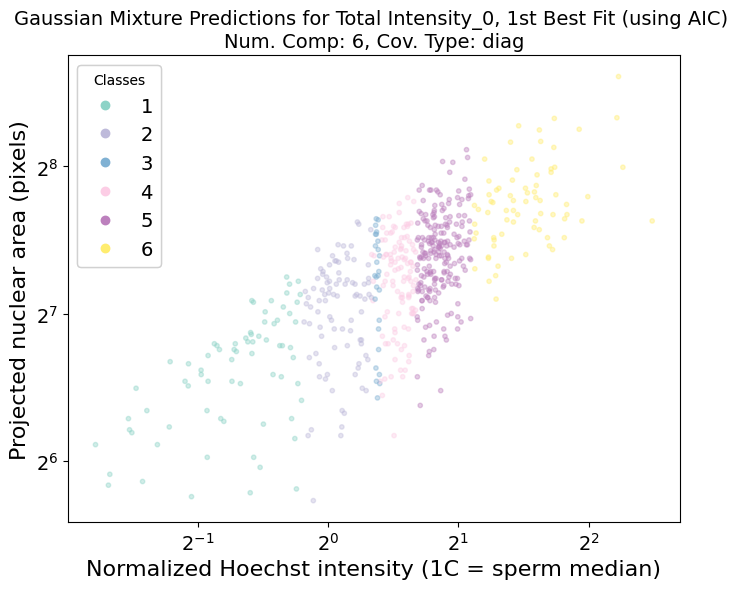

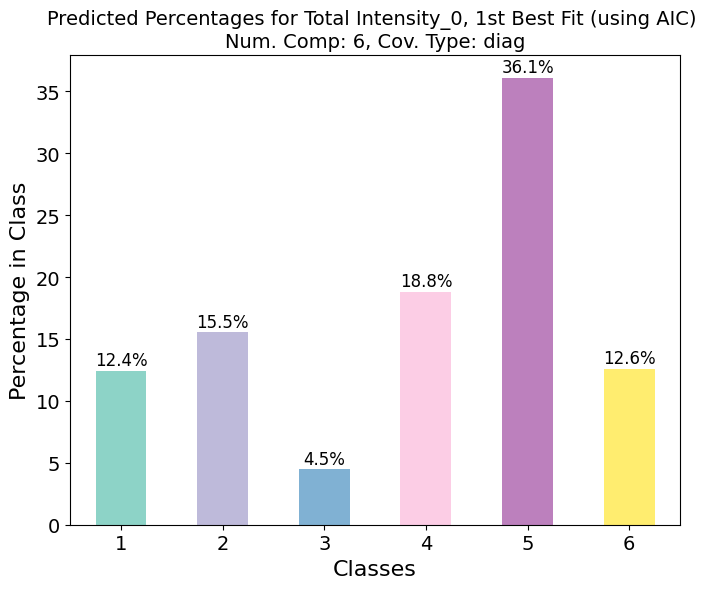

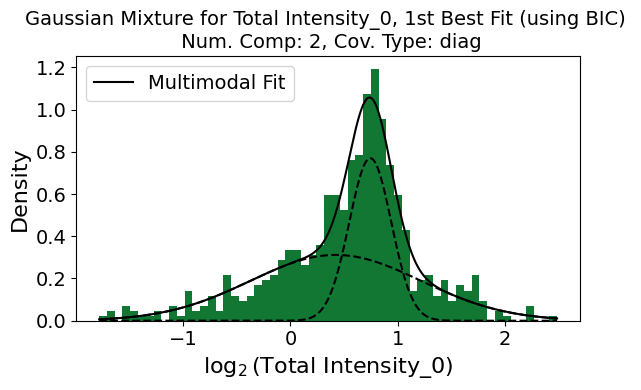

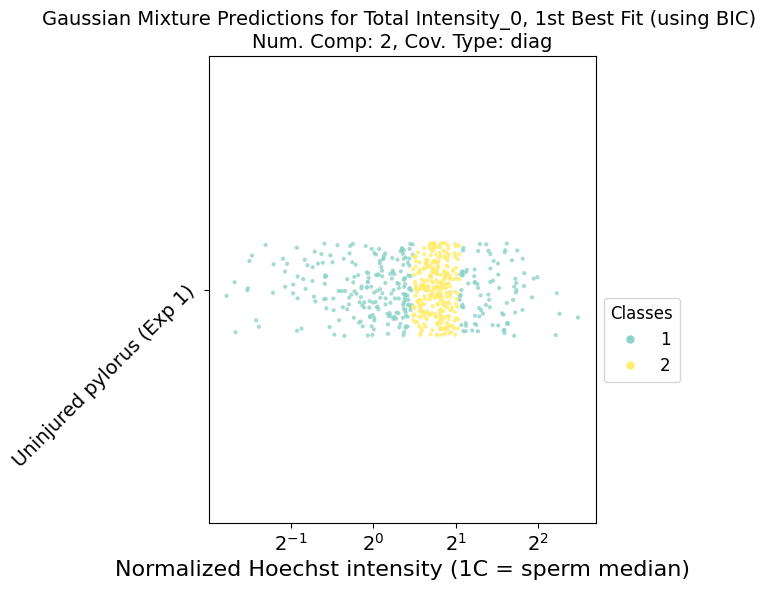

<Figure size 640x480 with 0 Axes>

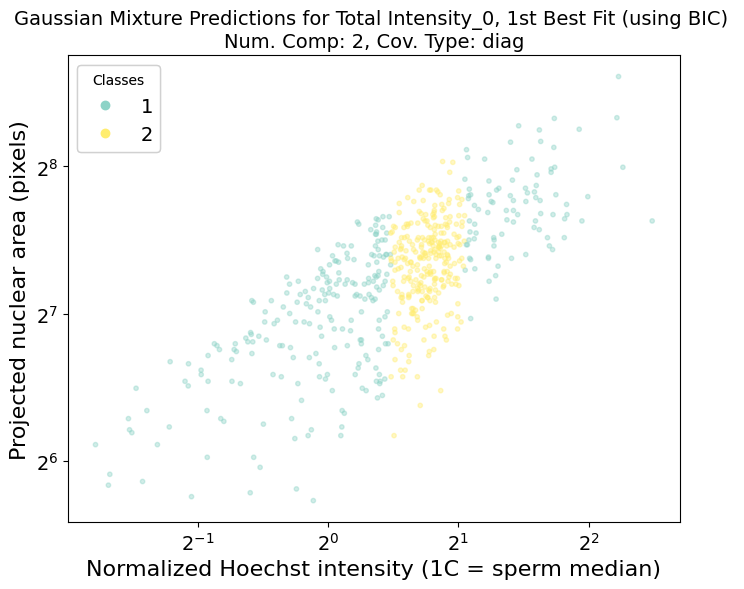

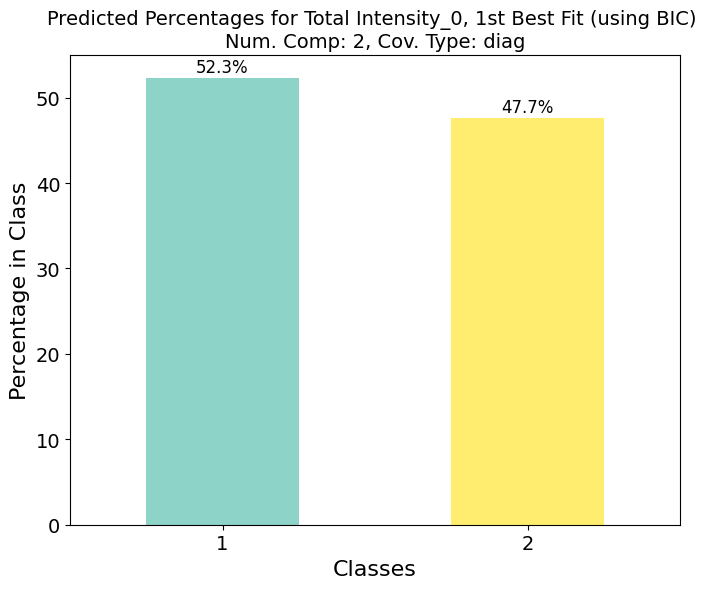

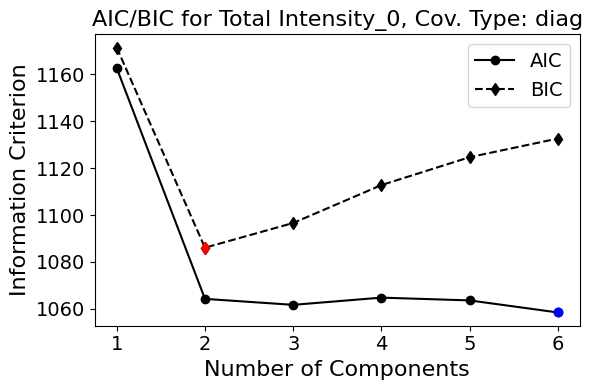

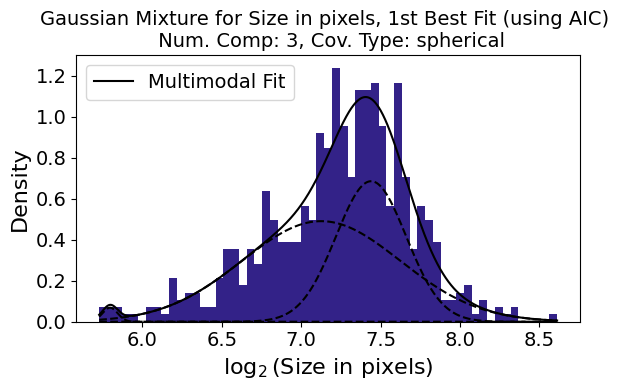

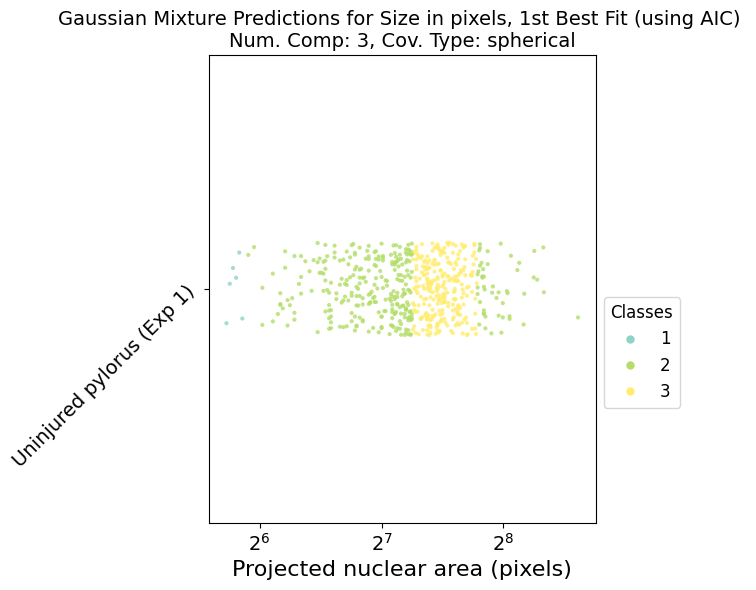

<Figure size 640x480 with 0 Axes>

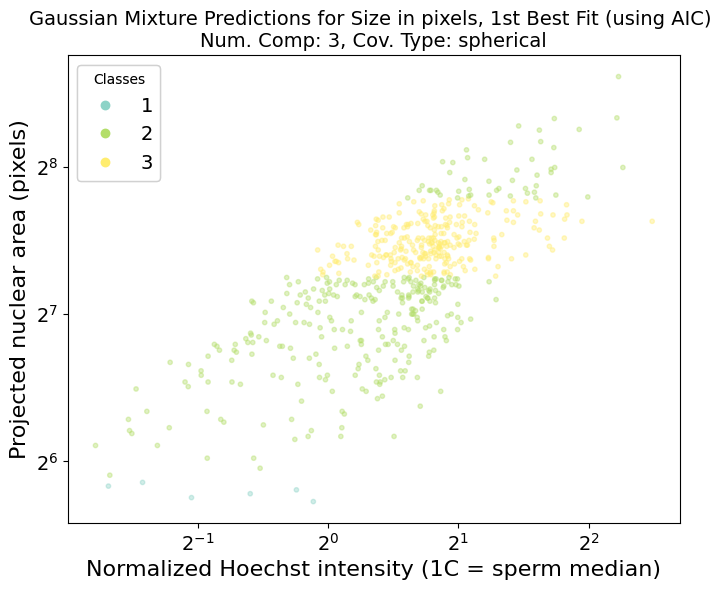

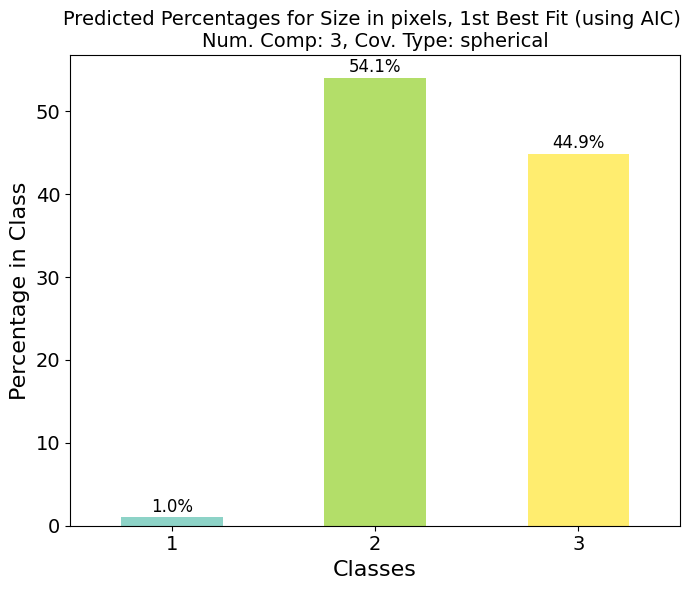

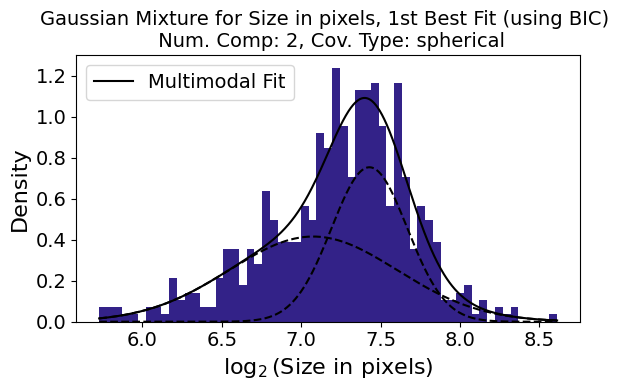

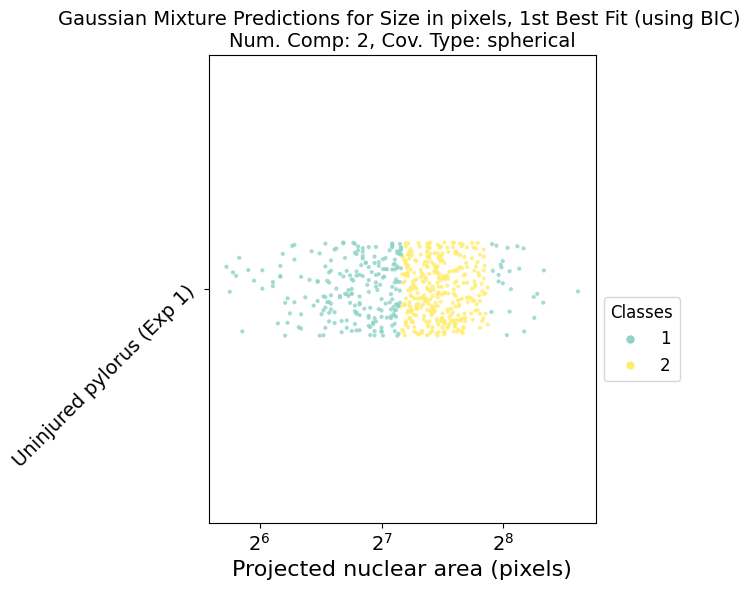

<Figure size 640x480 with 0 Axes>

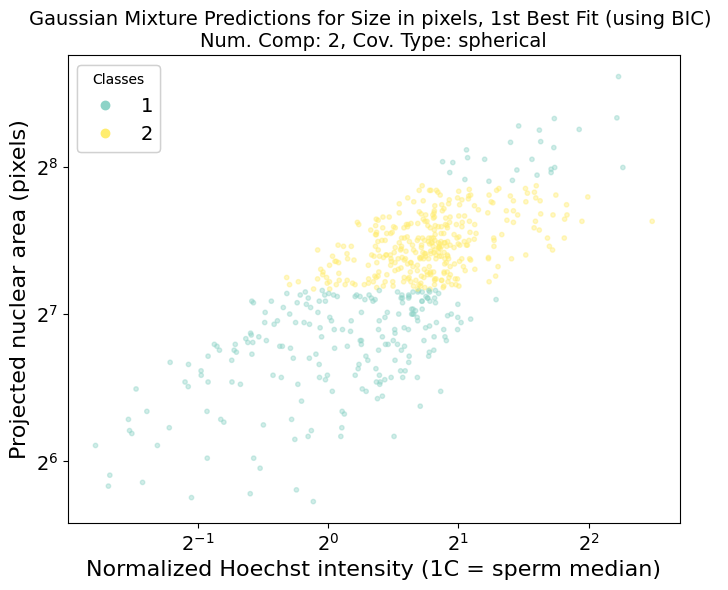

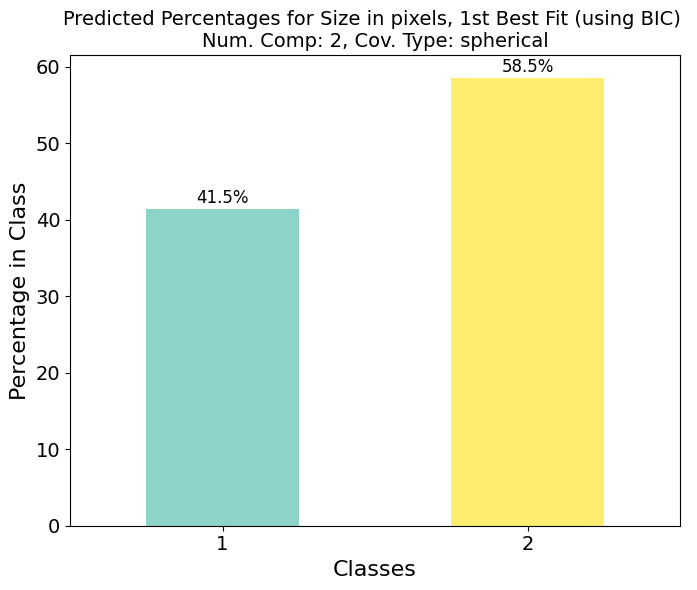

1D curve fitting done


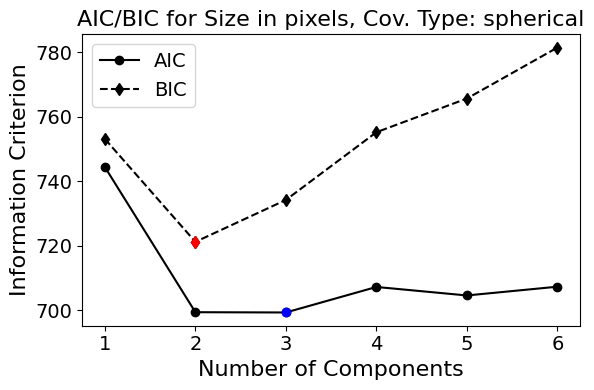

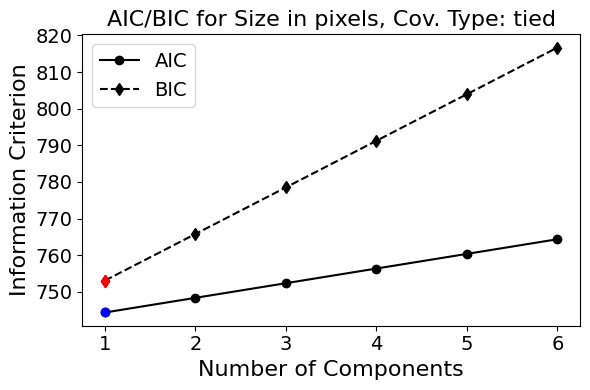

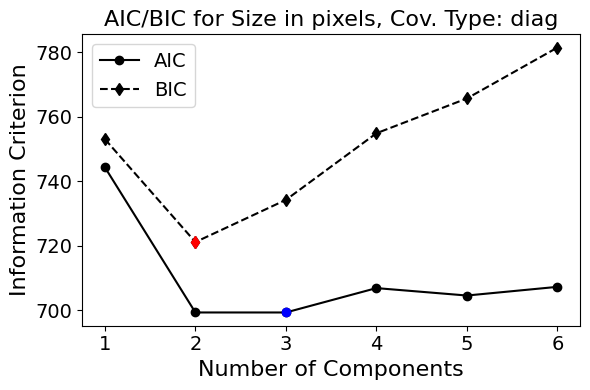

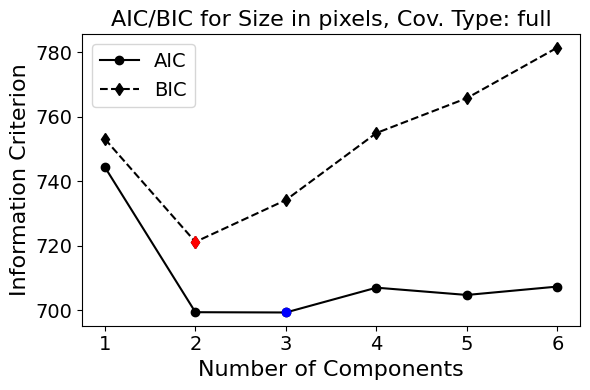

In [ ]:
Full_CurveFits(Char1, Char2, 1,
               1, 1, 6,      # curvefit_1d=1, search 1..6 components
               0, 0, 0,      # curvefit_2d=0
               PlotScheme)
print('1D curve fitting done')

### 2D Gaussian mixture (author code, 1–5 components, all four covariance types)

The paper's Fig. 3C analysis: a 2D GMM on (normalized Hoechst intensity, projected area), searching 1–5 components; the paper reports both AIC and BIC selected five components (Fig. S5K–M). The pinned author code searches **all four covariance types** (spherical, tied, diagonal, full) with its own settings (`n_init=500`, `tol=1e-7`, `max_iter=5000`); we run it unchanged. The AIC/BIC tables and best-fit curves are saved under `/content/Results/ispy_colab/`. This cell is the slowest of the notebook (roughly 15–25 minutes on CPU).

**2D GMM（日本語）:** 正規化強度×面積の 2D GMM を、著者コード既定の 4 種類の共分散・成分数 1〜5 で探索します（Fig. 3C 解析）。n_init=500 のため最も時間がかかり、15〜25 分程度です。

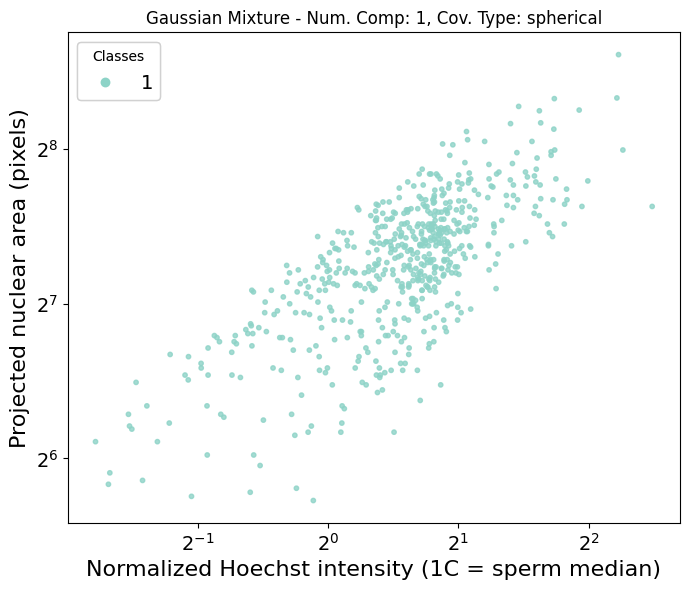

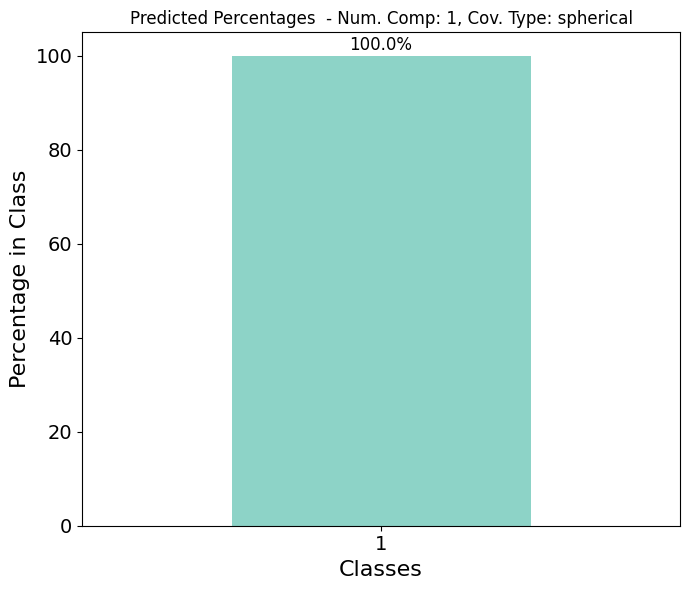

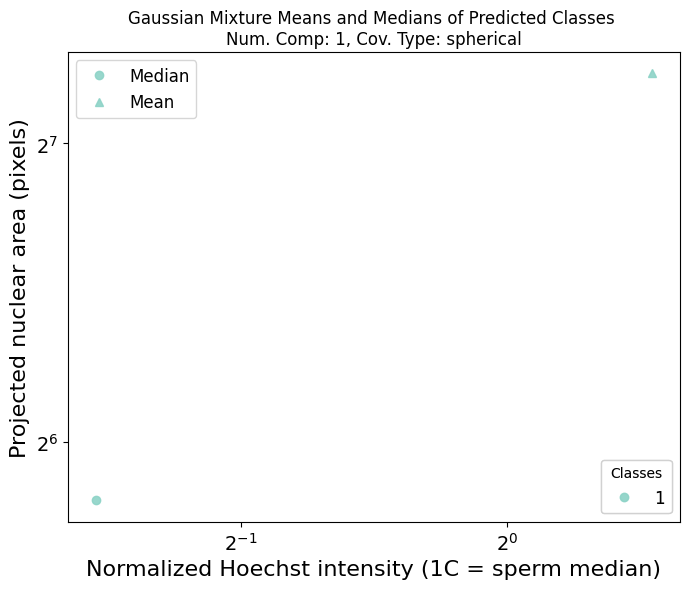

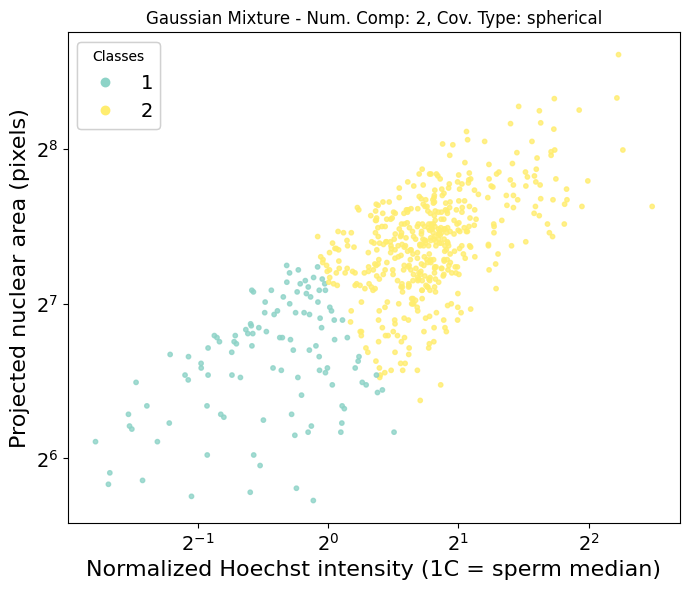

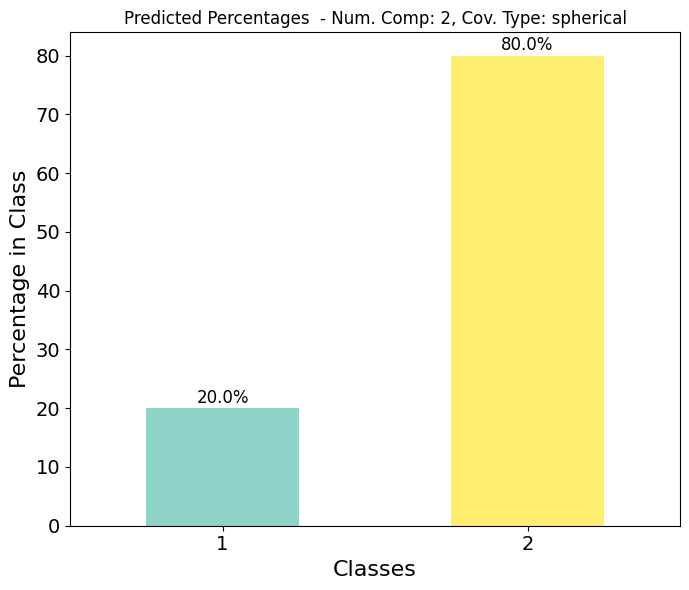

...

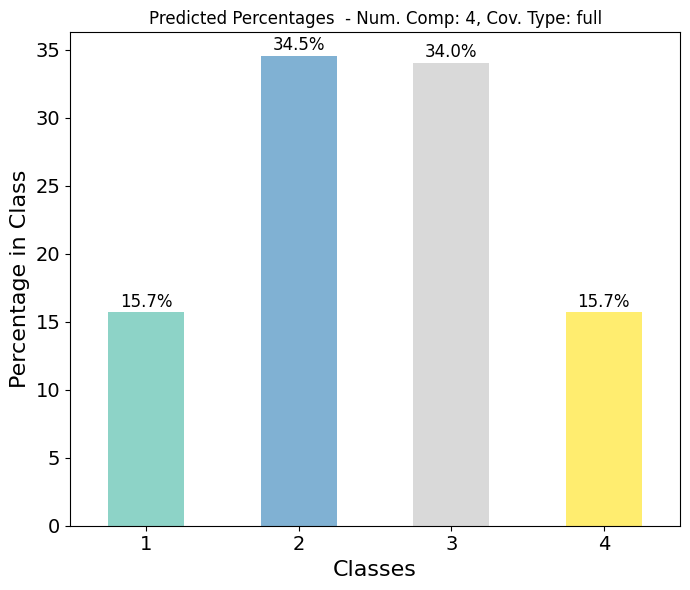

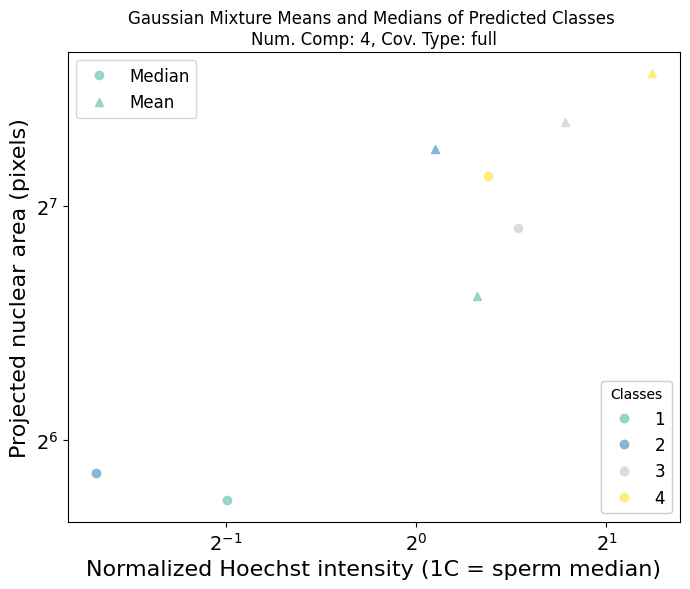

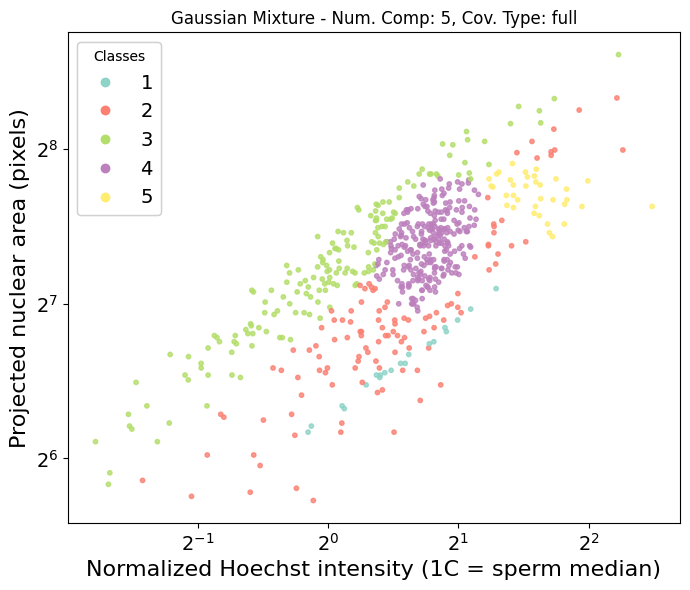

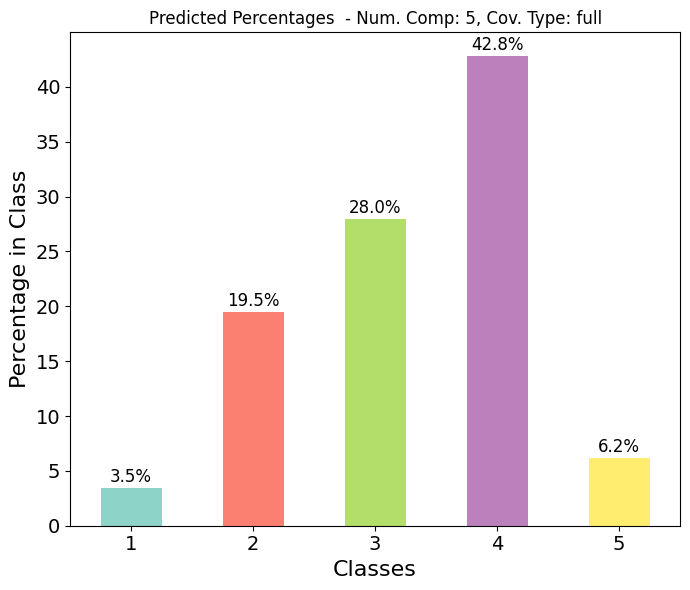

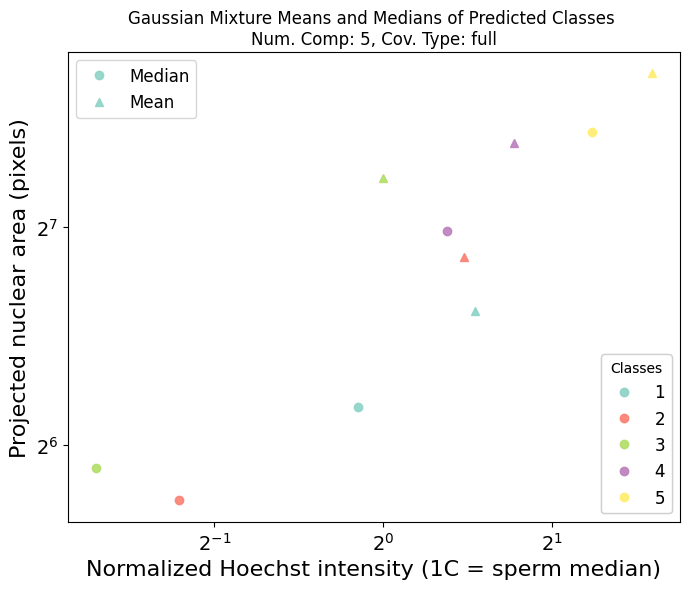

2D curve fitting done


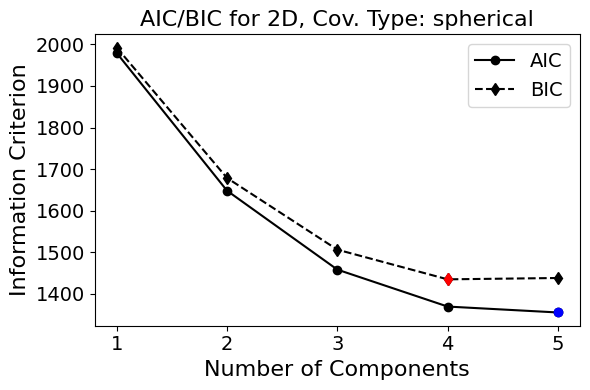

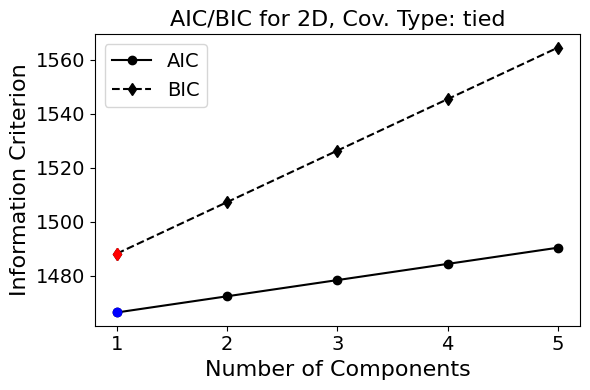

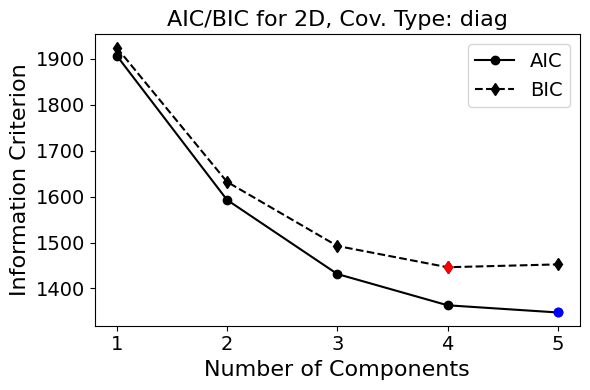

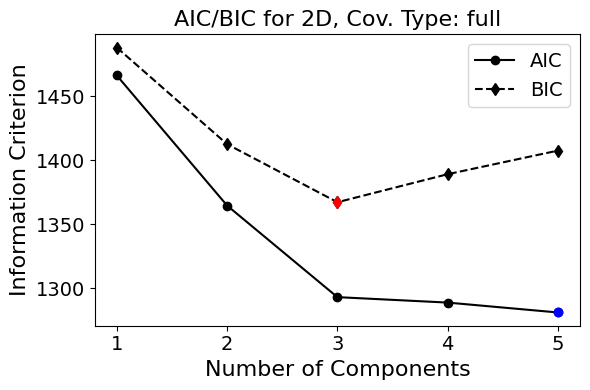

In [ ]:
Full_CurveFits(Char1, Char2, 1,
               0, 0, 0,      # curvefit_1d=0
               1, 1, 5,      # curvefit_2d=1, search 1..5 components
               PlotScheme)
print('2D curve fitting done')

### Model selection results (author ReadMe)

The author's ReadMe file records the AIC/BIC values per component count and covariance. We print the relevant blocks; the full file is saved under `/content/Results/ispy_colab/Data/ReadMe_Data.txt`.

**モデル選択（日本語）:** 著者 ReadMe の AIC/BIC 値を表示します（完全版は Results ディレクトリに保存）。


In [ ]:
import re
readme = open('/content/Results/ispy_colab/Data/ReadMe_Data.txt').read()
i = readme.find('1D Gaussian')
print(readme[i:i+2500] if i >= 0 else readme[:2500])

Important Data for the Plots Generated 
Date Generated: 2026-10-04 
############################## 
Files used for these graphs: 
/content/proc/pylorus_uninjured_exp1_norm.csv with legend Uninjured pylorus (Exp 1) 
############################## 
Char. 1: Total Intensity_0 normalized by None 
Scale: Log (with base 2)
Histogram normalized to 1? False
Char. 2: Size in pixels normalized by None 
Scale: Log (with base 2)
Histogram normalized to 1? False
############################## 
Voxel size: [1, 1]
Total Number of Objects: 579
############################## 
Curve Fit Percentages for Total Intensity_0, 1st Best Fit (using AIC) 
Num. Comp: 6, Cov. Type: diag 
Class 1: 12.435233160621761% 
Class 2: 15.544041450777202% 
Class 3: 4.490500863557859% 
Class 4: 18.825561312607945% 
Class 5: 36.096718480138165% 
Class 6: 12.607944732297064% 
############################## 
Averages for each cluster
Class 1: Median: 0.2974447757699319, Mean: 0.6059702258109025
Class 2: Median: 0.88300650871538

### Ploidy-class interpretation and quantitative plausibility check

Following the paper (and its Table S1), the five ordered components correspond to the ploidy classes `<2C/Unclassified, 2C, 4C, 8C, >=16C`. We summarize the 2D mixture's per-class fractions, means, and fold increases of the normalized intensity. Two paper references are printed for comparison: the pooled uninjured class fractions (Table S1, 2D diagonal row) and the fold increase per ploidy doubling (1.87–1.97x). A single sample and the anchor convention can shift individual classes; the fold-increase ladder is the scale-free check.

**結果表（日本語）:** 2D 混合モデルの各クラスの割合・平均・倍増率を表にし、論文 Table S1（プールした未損傷サンプル）および倍増率 1.87〜1.97 倍と比較します。単一サンプルのためクラス毎の対応は参考値です。

In [ ]:
import pandas as pd, numpy as np

PRED_CSV = '/content/Results/ispy_colab/Curve_Fitting/Char_Total Intensity_0/Data/Predictions_output.csv'
p = pd.read_csv(PRED_CSV, sep=';')
INT = 'Normalized Hoechst intensity (1C = sperm median)'      # per-nucleus normalized intensity
one_d = [c for c in p.columns if c.startswith('Total Intensity_0_N')][0]
two_d_cols = [c for c in p.columns if c.startswith('2D_N')]
print('prediction columns:', [c for c in p.columns if '_N_' in c or c.startswith('2D')])
# the paper's 2D analysis uses five components -> prefer the N=5 column
five = [c for c in two_d_cols if '_N_5_' in c]
two_d = five[0] if five else two_d_cols[-1]
print('1D column:', one_d, '| 2D column:', two_d)

PAPER_NAMES = ['<2C/Unclassified', '2C', '4C', '8C', '>=16C']   # paper's ordered naming (Table S1)
TABLE_S1_2D_DIAG = [31.0, 52.8, 14.1, 2.1, 0.0]                # pooled uninjured, paper Table S1 (Fig. S5N row)

def summarize(col):
    g = p.groupby(col)[INT].agg(['count', 'mean', 'median']).sort_index()
    g['fraction_%'] = 100 * g['count'] / g['count'].sum()
    g['fold_increase_next'] = g['mean'].shift(-1) / g['mean']
    if len(g) == len(PAPER_NAMES):
        g.index = PAPER_NAMES
    return g

t2d = summarize(two_d)
print('2D mixture (all covariance types searched; showing %s)' % two_d)
print(t2d.to_string(float_format=lambda v: f'{v:.3f}'))
print()
print('Paper Table S1 (2D, diagonal, pooled uninjured, %%):', TABLE_S1_2D_DIAG)
print('Paper fold increase per ploidy doubling: 1.87-1.97x (3.13x into >=16C)')
print('Paper (Fig. 3D): majority of uninjured pyloric nuclei are 2C.')
t2d.to_csv('/content/Results/ispy_colab/colab_2D_summary.csv')

prediction columns: ['Total Intensity_0_N_6_Cov_diag', 'Total Intensity_0_N_2_Cov_diag', 'Size in pixels_N_3_Cov_spherical', 'Size in pixels_N_2_Cov_spherical', '2D_N_1_Cov_spherical', '2D_N_2_Cov_spherical', '2D_N_3_Cov_spherical', '2D_N_4_Cov_spherical', '2D_N_5_Cov_spherical', '2D_N_1_Cov_tied', '2D_N_2_Cov_tied', '2D_N_3_Cov_tied', '2D_N_4_Cov_tied', '2D_N_5_Cov_tied', '2D_N_1_Cov_diag', '2D_N_2_Cov_diag', '2D_N_3_Cov_diag', '2D_N_4_Cov_diag', '2D_N_5_Cov_diag', '2D_N_1_Cov_full', '2D_N_2_Cov_full', '2D_N_3_Cov_full', '2D_N_4_Cov_full', '2D_N_5_Cov_full']
1D column: Total Intensity_0_N_6_Cov_diag | 2D column: 2D_N_5_Cov_spherical
2D mixture (all covariance types searched; showing 2D_N_5_Cov_spherical)
                  count  mean  median  fraction_%  fold_increase_next
<2C/Unclassified     11 0.355   0.352       1.900               1.901
2C                   56 0.676   0.667       9.672               1.812
4C                  164 1.224   1.194      28.325               1.424
8C   

### Spatial ploidy map (author `PredictionImage`, comparable to Fig. 3F)

`PredictionImage` reads the Object Identities file and paints every segmented nucleus with its predicted class color, producing the paper's spatial output. We generate it from the saved predictions and display the 2D-mixture map PNG below. Colors come from the author-configured `Set3` colormap; class 0 (black) is background. This is a **model prediction overlay** on the actual sample image, not a paper figure.

**空間マップ（日本語）:** `PredictionImage` が Object Identities を読み込み、各核を予測クラスの色で塗った Fig. 3F 相当の空間マップを作成・表示します（モデル予測のオーバーレイです）。


/content/ispy/tools/image_output/Image_Output.py:245: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(8, 8 * Xs / Ys))


/content/Results/ispy_colab/Curve_Fitting/Both_Chars/Prediction_Images/Uninjured pylorus (Exp 1)/PredictionMax_2D_N_1_Cov_diag_Colored.png
/content/Results/ispy_colab/Curve_Fitting/Both_Chars/Prediction_Images/Uninjured pylorus (Exp 1)/PredictionMax_2D_N_1_Cov_full_Colored.png
/content/Results/ispy_colab/Curve_Fitting/Both_Chars/Prediction_Images/Uninjured pylorus (Exp 1)/PredictionMax_2D_N_1_Cov_spherical_Colored.png
/content/Results/ispy_colab/Curve_Fitting/Both_Chars/Prediction_Images/Uninjured pylorus (Exp 1)/PredictionMax_2D_N_1_Cov_tied_Colored.png
/content/Results/ispy_colab/Curve_Fitting/Both_Chars/Prediction_Images/Uninjured pylorus (Exp 1)/PredictionMax_2D_N_2_Cov_diag_Colored.png
/content/Results/ispy_colab/Curve_Fitting/Both_Chars/Prediction_Images/Uninjured pylorus (Exp 1)/PredictionMax_2D_N_2_Cov_full_Colored.png
/content/Results/ispy_colab/Curve_Fitting/Both_Chars/Prediction_Images/Uninjured pylorus (Exp 1)/PredictionMax_2D_N_2_Cov_spherical_Colored.png
/content/Results/

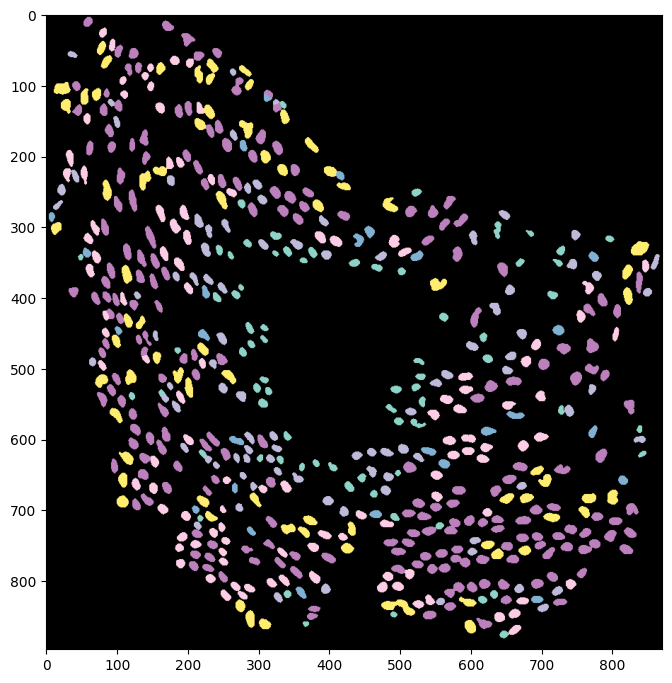

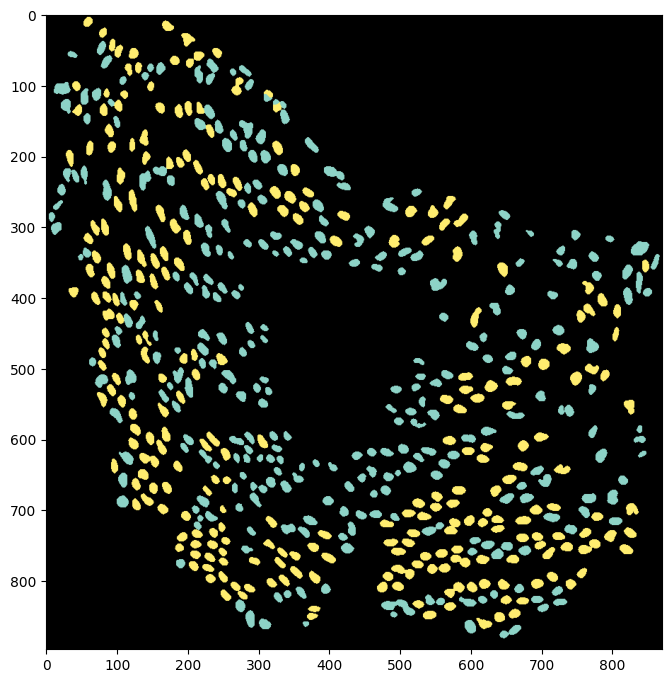

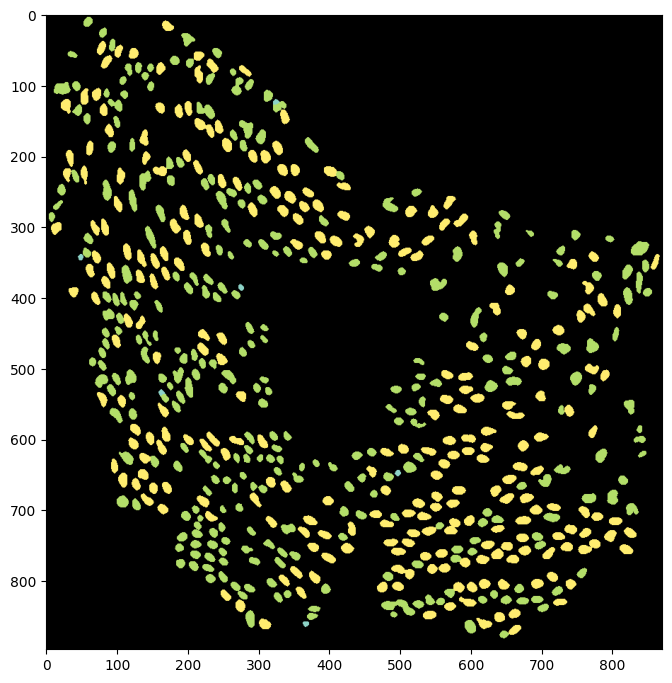

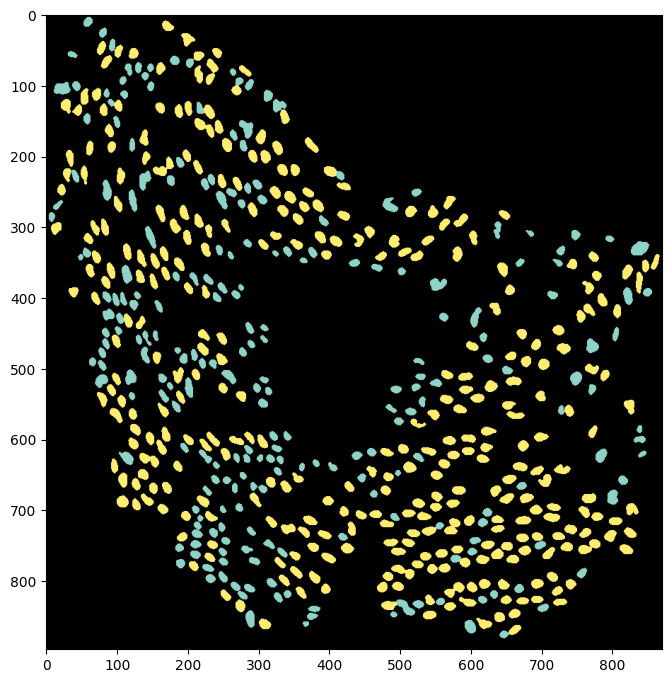

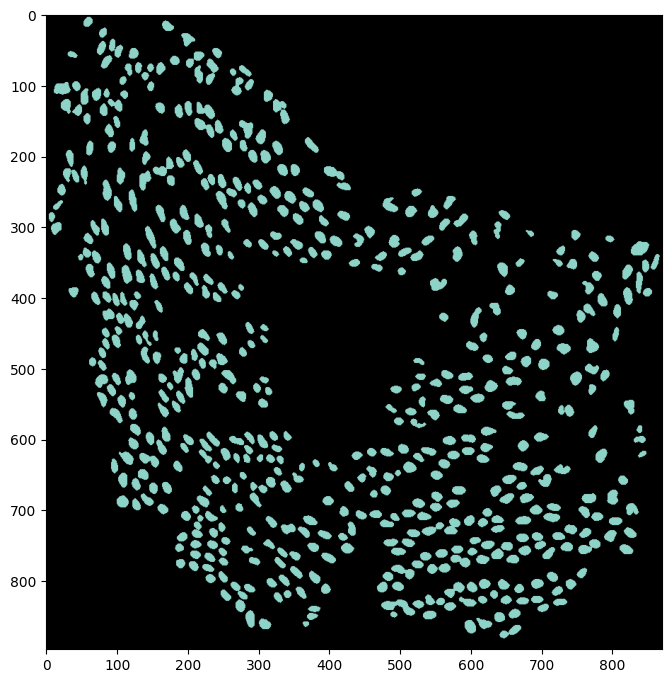

...

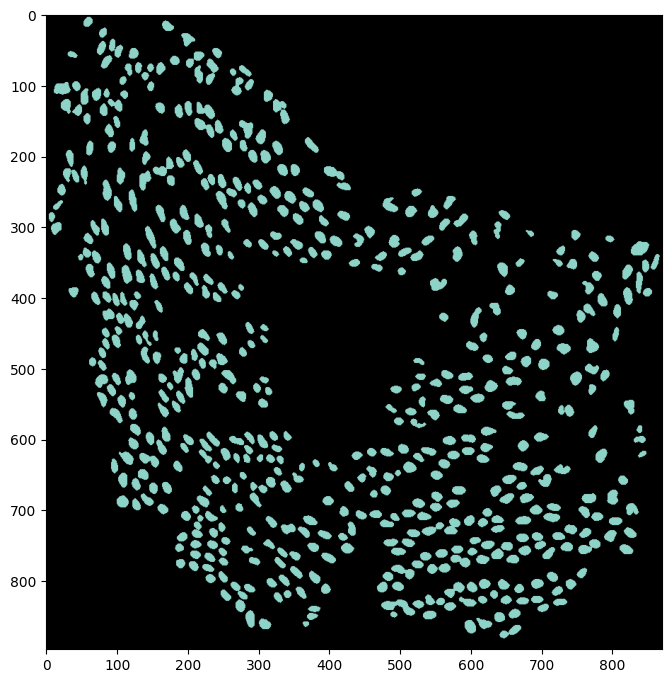

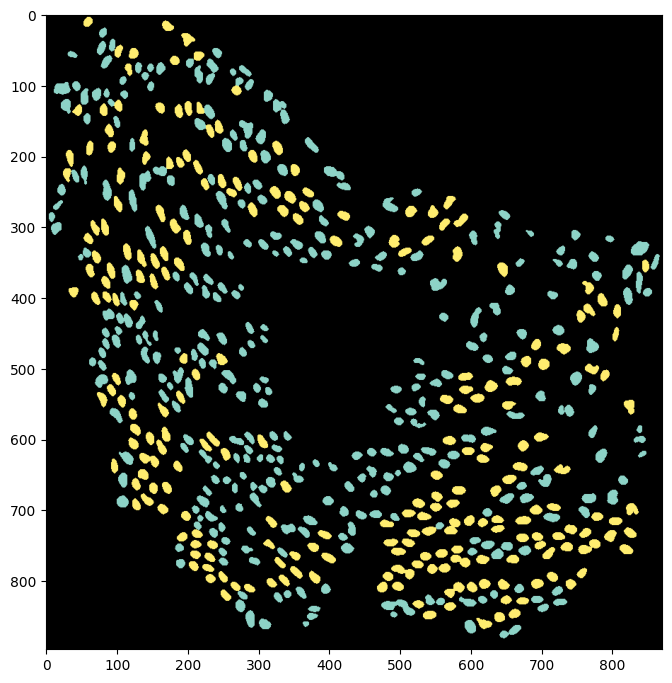

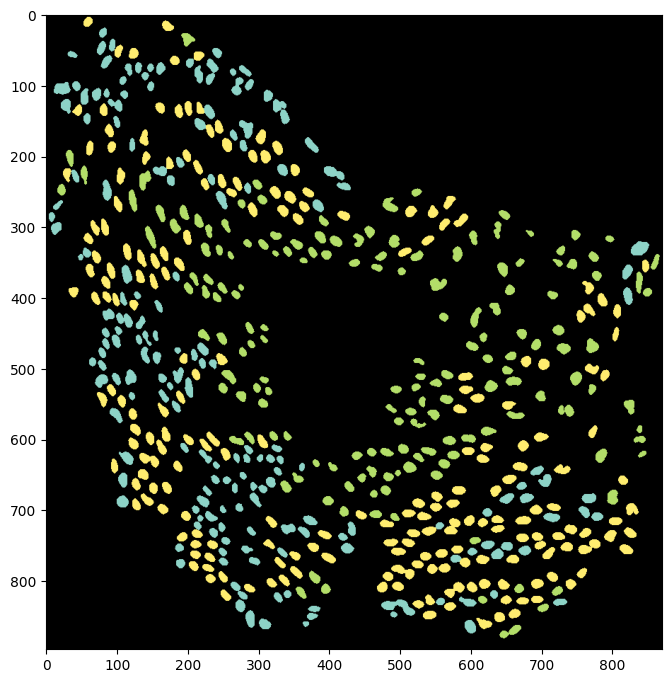

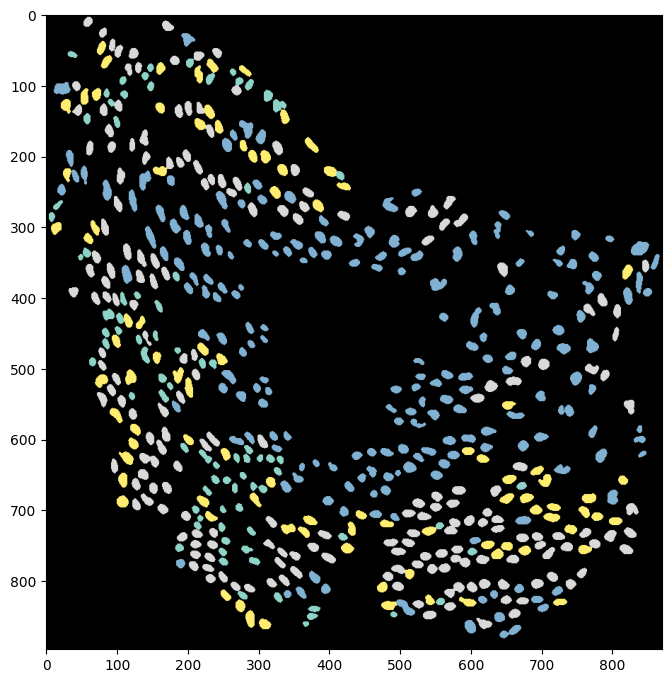

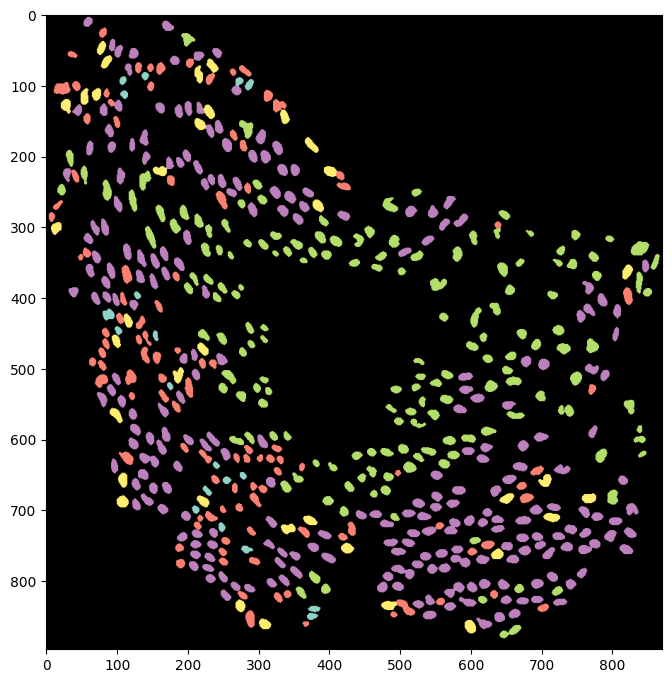

In [ ]:
PredictionImage(['/content/data/Object_Identities_1.h5'], 'labelimage_oid',
                PlotScheme, Char1, Char2, 2, [1, 1, 1], 0)
import glob
maps = sorted(glob.glob('/content/Results/ispy_colab/**/Prediction_Images/**/PredictionMax_*_Colored.png', recursive=True))
print('\n'.join(maps))

### Display the spatial ploidy map inline

The colored map PNG saved by `PredictionImage` for the 2D-mixture prediction is loaded and shown. The map is oriented like the input sum projection (anterior–posterior tissue axis left-to-right, as in the paper's Figure 3F for the uninjured pylorus).

**マップ表示（日本語）:** `PredictionImage` が保存した 2D 混合モデル予測のカラー PNG を読み込んで表示します。向きは入力の和投影画像と同じです。


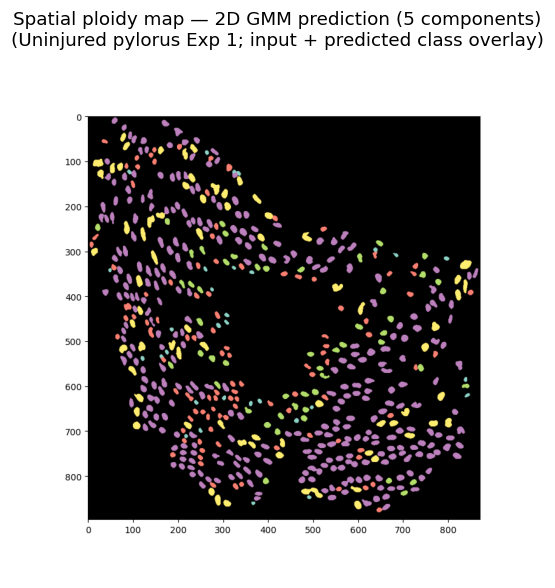

displayed: /content/Results/ispy_colab/Curve_Fitting/Both_Chars/Prediction_Images/Uninjured pylorus (Exp 1)/PredictionMax_2D_N_5_Cov_diag_Colored.png


In [ ]:
from matplotlib import image as mpimg
# the paper's Fig. 3C/F map uses the five-component 2D mixture -> show the N_5 map
map5 = [q for q in maps if '_N_5_' in q]
map5d = [q for q in map5 if '_Cov_diag' in q] or map5
show = map5d[0] if map5d else maps[-1]
img = mpimg.imread(show)
fig, ax = plt.subplots(figsize=(6, 6 * img.shape[0] / img.shape[1]), dpi=110)
ax.imshow(img)
ax.set_title('Spatial ploidy map — 2D GMM prediction (5 components)\n(Uninjured pylorus Exp 1; input + predicted class overlay)')
ax.set_axis_off(); plt.show()
print('displayed:', show)

## Interpretation, limitations, and validation record

**What was reproduced (executed):** the paper's iSPy pipeline for one sample — spermatid normalization, 1D and 2D Gaussian-mixture classification with the author's exact optimizer settings and model-selection criteria, and the colored spatial ploidy map (Fig. 3F-type output for the uninjured condition). Expected paper observation for uninjured pylori: the majority of nuclei are 2C, with a mixture up to 8C; normalized-intensity class means should roughly double per class (paper: 1.87–1.97x).

**Limitations / 未検証の範囲（日本語）:**
- 単一サンプル（Uninjured, Exp 1）のみ。損傷条件（mild/severe）との比較、Arabidopsis・ヒト心臓の解析、フローサイトメトリー検証は含みません。
- 'Bad Nuclei'（191 個）の除外は CSV の User Label 列に基づく（論文の hand-selection ステップの結果）。
- 2D GMM は対角共分散のみ探索（STAR Methods の Drosophila 指定 "spherical or diagonal" のうち Fig. 3C と同じ diagonal）。AIC/BIC の全共分散比較は省略。
- 著者コードは乱数シードを固定していないため、GMM の詳細（特に境界付近の割当）は実行毎に多少変わり得ます。
- 面積はピクセル単位（ilastik はボクセルサイズを保持しない）。

**Validation record:** executed top-to-bottom on a fresh Colab CPU runtime; the archived `*_output.ipynb` of that run is the delivered evidence. Source files were sha256-verified against pinned commit `8c2c51c317c4` and the OSF release metadata.

## References
- Russell N.J. et al. (2025) *Spatial ploidy inference using quantitative imaging.* bioRxiv 10.1101/2025.03.11.642217; Cell Reports Methods 5:101249.
- iSPy code: N.J. Russell, GitLab `devplantpatterning/Publications/ispy-inferring-spatial-ploidy`, commit `8c2c51c317c4`, MIT License (fetched in notebook).
- Data: OSF node `wkaf5` (*Drosophila Data*), files listed above; code mirror: OSF node `tgbwk`.
